In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from src.util import read_params_file, pspl_model, category_cmap
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
import hdbscan
import umap
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt
from src.preprocessing import preprocess_lc

Define some style info for plots

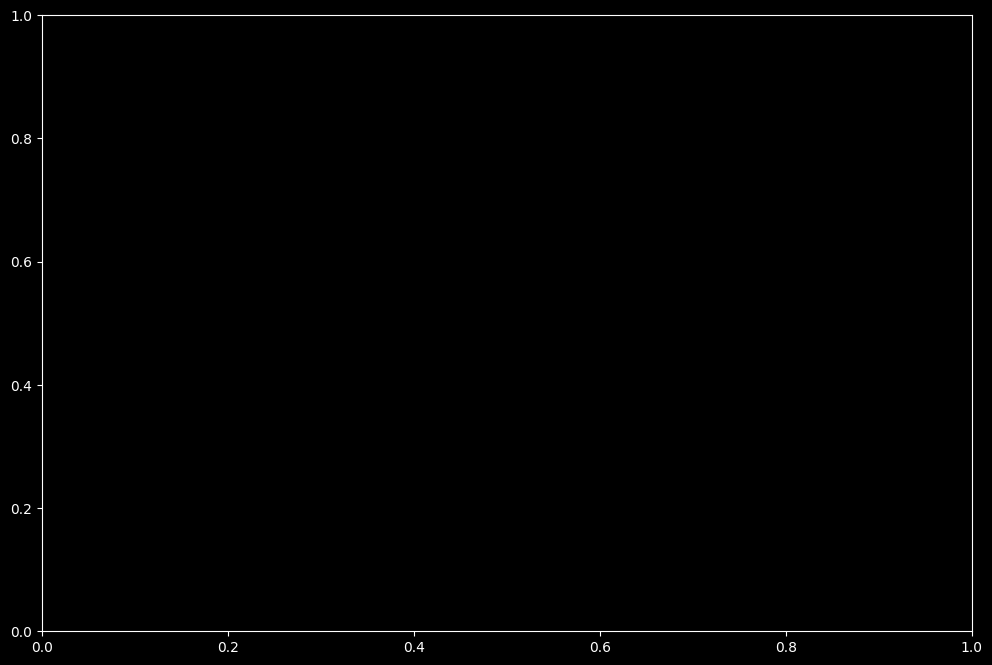

In [3]:
plt.style.use('default')
plt.rcParams["figure.figsize"] = (12, 8)
plt.style.use('dark_background')
plt.set_cmap('magma')
plt.tick_params(axis='x', colors='w')
plt.tick_params(axis='y', colors='w')

# 6. Load Features and Prepare Input Matrix
- Reload extracted feature table  
- Remove non-feature columns such as event names  
- Scale numerical features for embedding and clustering  

In [4]:
features_df = pd.read_csv("data/features/features_ogle2025.csv")
features_df.head()

,n_points,duration,cadence_med,flux_mean,flux_std,flux_amp,flux_skew,flux_kurt,amp_norm,std_norm,flux_asym,rise_fall_ratio,fwhm_time,abbe_value,smoothness,outlier_frac,ls_top1,ls_top2,ls_top3,event
0,4569,3178.62416,0.048045,1.077983,0.085507,1.069432,0.811660,6.200264,0.992067,0.079321,0.018457,15.843277,2356.39568,0.850413,0.063426,0.004377,0.013095,0.008418,0.007952,blg-0491
1,2466,3174.66809,0.060230,1.170225,0.187046,1.831861,1.002385,4.750533,1.565392,0.159838,-0.166192,20.614887,3122.73629,0.784735,0.137076,0.009327,0.166154,0.109379,0.079690,blg-0801
2,4315,3177.66444,0.048150,1.275117,0.311281,2.551203,1.639576,5.564362,2.000760,0.244120,-0.285650,15.931352,2710.69499,0.491143,0.221417,0.019467,2.884965,1.892165,0.604476,blg-0490
3,2387,3174.66809,0.061825,1.117995,0.336294,4.984287,10.040832,115.719071,4.458237,0.300801,-0.597205,27.336957,18.99726,0.066117,0.100666,0.011730,0.541630,0.494291,0.489079,blg-0800
4,318,3160.66304,1.956380,1.133161,0.536728,8.452286,12.119374,168.126551,7.459036,0.473656,-0.096590,12.757479,0.00000,0.403397,0.119879,0.009434,6.259907,6.180807,5.829716,blg-0239


In [5]:
X = features_df.drop(columns=["event"], errors="ignore").fillna(0)
X_scaled = StandardScaler().fit_transform(X)

# 7. UMAP Dimensionality Reduction
- Configure UMAP hyperparameters  
- Generate a 2D embedding of the feature space  
- Store UMAP coordinates in the feature DataFrame  


In [6]:
umap_model = umap.UMAP(
    n_neighbors=30,      # local neighborhood size
    min_dist=0.2,        # controls cluster tightness
    n_components=2,      # 2D embedding
    metric="euclidean",
    random_state=42
)

embedding = umap_model.fit_transform(X_scaled)
features_df["umap_x"] = embedding[:, 0]
features_df["umap_y"] = embedding[:, 1]

/opt/homebrew/Caskroom/miniconda/base/envs/a356/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# 8. Visualizing UMAP Embeddings
- Plot the overall UMAP embedding  
- Generate additional visualizations colored by selected features  
- Save figures for documentation and review  

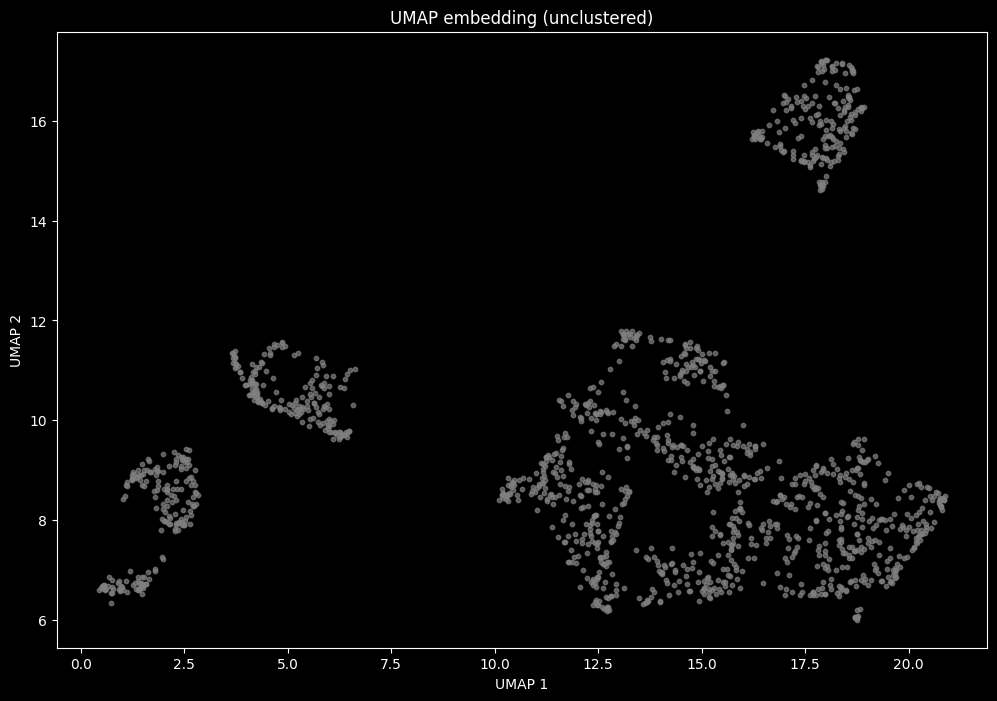

In [7]:
plt.scatter(
    features_df["umap_x"], features_df["umap_y"],
    s=10, alpha=0.7, c="gray"
)
plt.title("UMAP embedding (unclustered)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.savefig("figures/umap_ogle2025_unclustered.png", dpi=300, transparent=True)
plt.show()


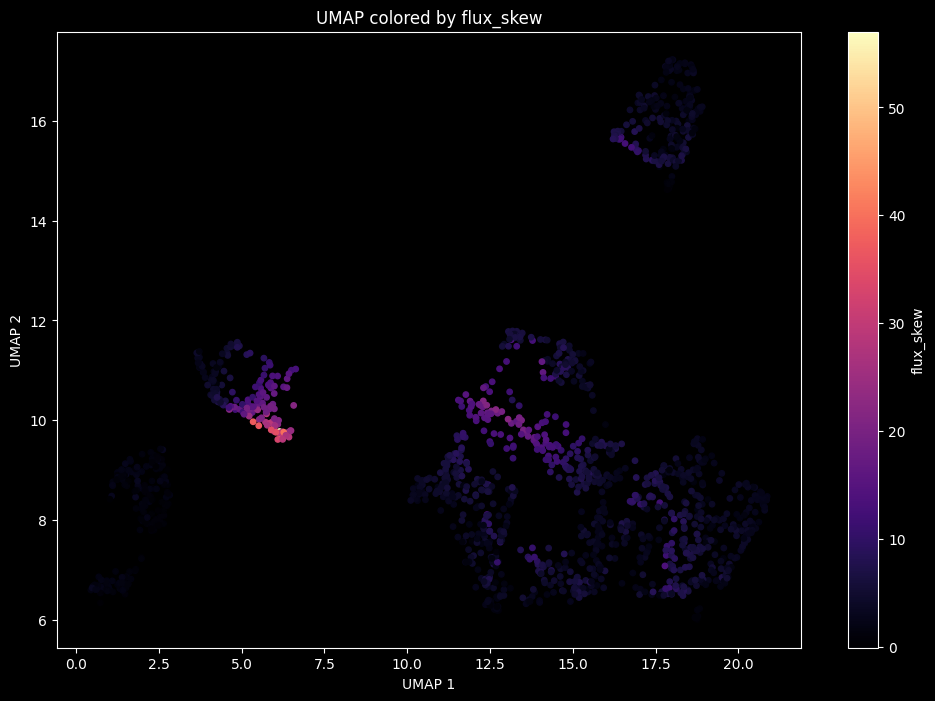

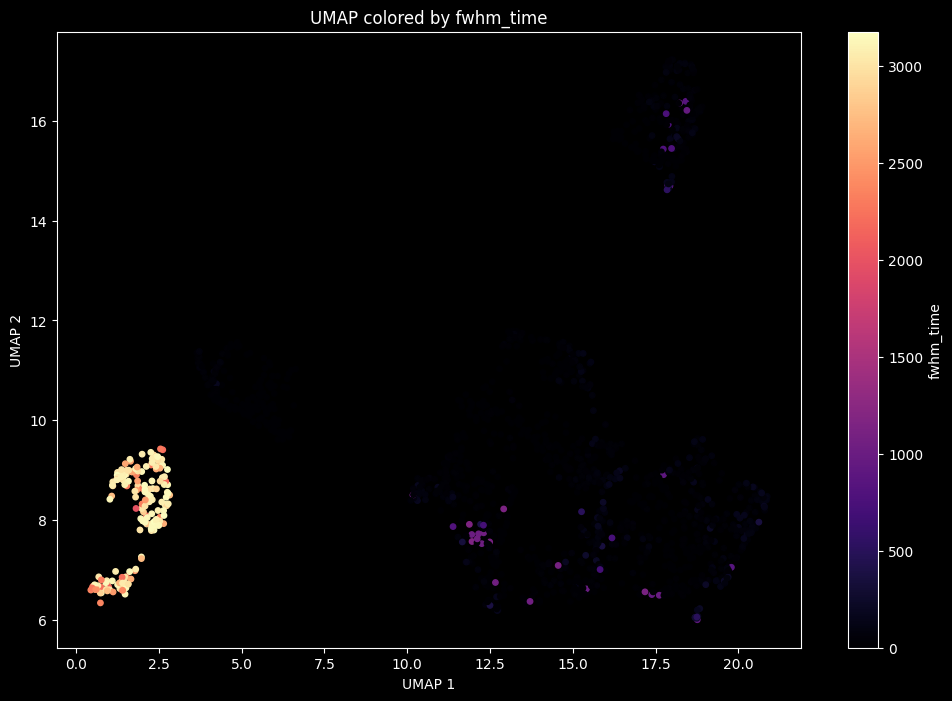

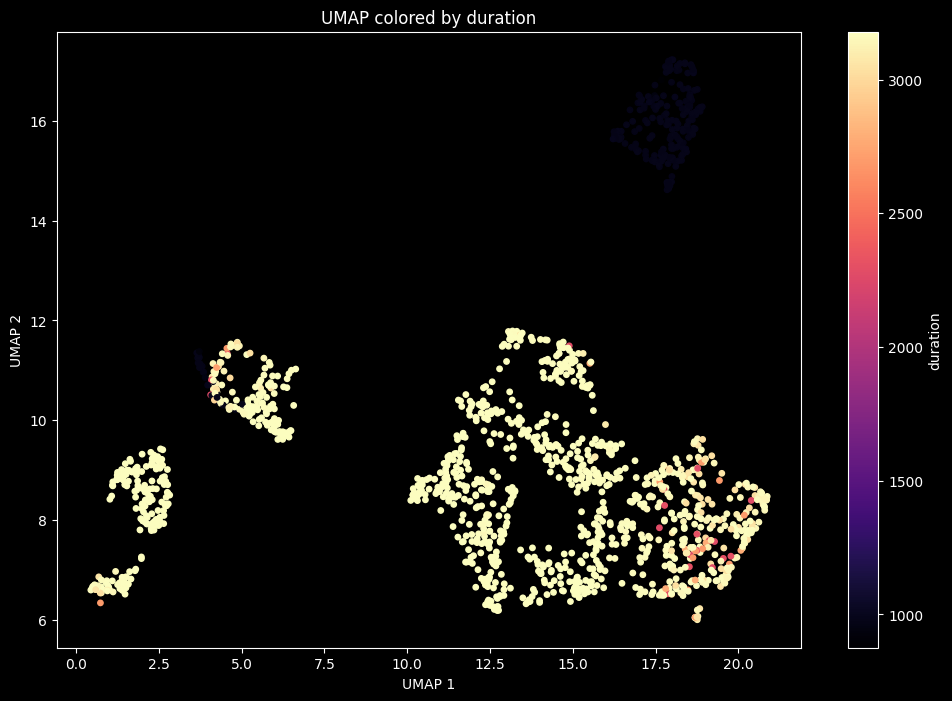

In [8]:
for col in ["flux_skew", "fwhm_time", "duration"]:
    plt.scatter(
        features_df["umap_x"], features_df["umap_y"],
        c=features_df[col], s=15
    )
    plt.title(f"UMAP colored by {col}")
    plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
    plt.colorbar(label=col)
    plt.savefig(f"figures/umap_ogle2025_{col}.png", dpi=300, transparent=True)
    plt.show()


# 10. HDBSCAN Clustering
- Fit the HDBSCAN clustering model  
- Extract cluster labels and add them to the DataFrame  
- Visualize the condensed cluster tree  

/opt/homebrew/Caskroom/miniconda/base/envs/a356/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/a356/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


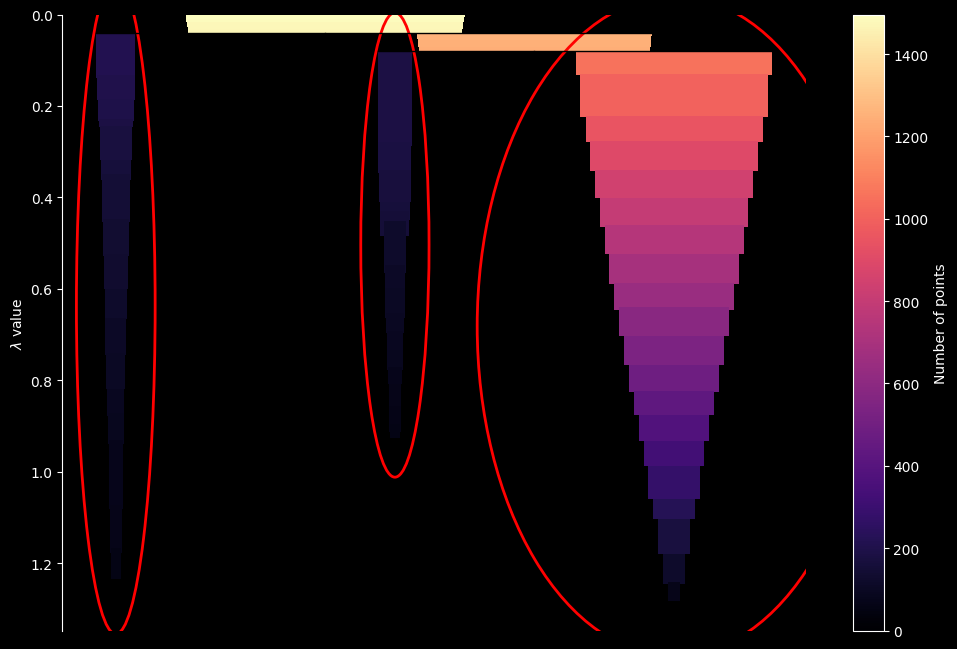

In [10]:
X = features_df.loc[:, features_df.columns.difference(['event', 'umap_x', 'umap_y'])]
selector = VarianceThreshold(threshold=1e-6)
X_reduced = selector.fit_transform(X)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_reduced)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,     # try 25–50 to start
    min_samples=5,          # how conservative the cluster core is
    cluster_selection_epsilon=0.05,
    gen_min_span_tree=True
)

labels = clusterer.fit_predict(X_scaled)
features_df["cluster"] = labels

clusterer.condensed_tree_.plot(select_clusters=True, cmap='magma')
plt.savefig("figures/hdbscan_condensed_tree_ogle2025.png", dpi=300, transparent=True)
plt.show()

# 11. Cluster Quality Diagnostics
- Examine cluster size distribution  
- Inspect cluster persistence values  
- Compute silhouette score and probability histograms  
- Select stable clusters based on persistence threshold  

In [11]:
for c in sorted(np.unique(labels)):
    size = (labels == c).sum()
    persistence = clusterer.cluster_persistence_[c]
    print(f"Cluster {c}: size={size}, persistence={persistence:.3f}")

Cluster -1: size=47, persistence=0.490
Cluster 0: size=211, persistence=0.532
Cluster 1: size=183, persistence=0.453
Cluster 2: size=1055, persistence=0.490


Silhouette: 0.75104
0 211
1 183
2 1055


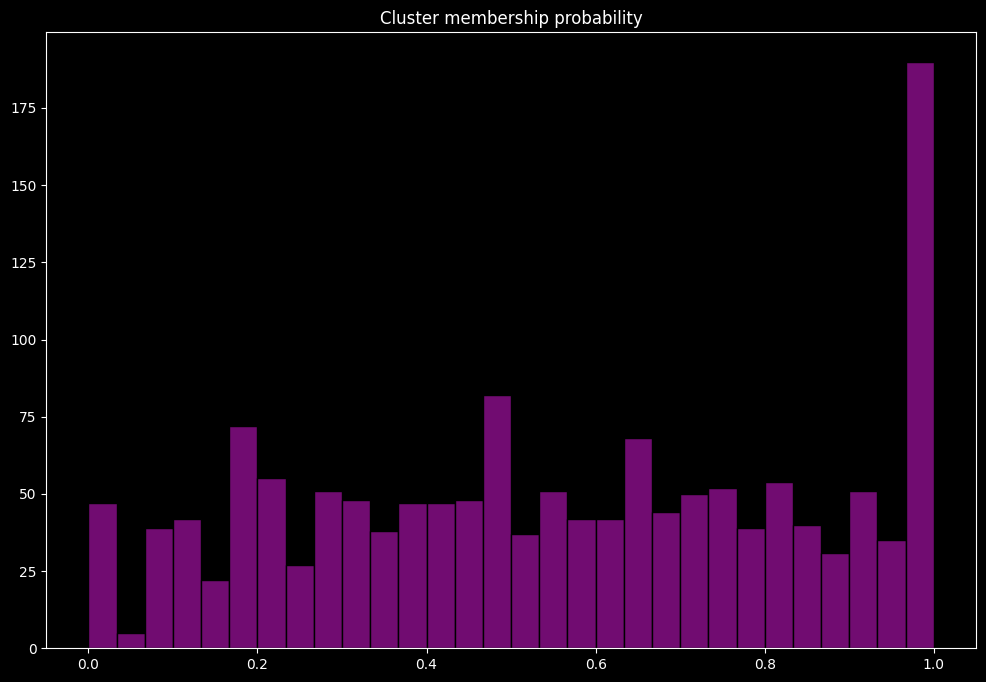

In [12]:
sil = silhouette_score(X_scaled, labels)
print(f"Silhouette: {sil:.5f}")

plt.hist(clusterer.probabilities_, bins=30, color='#710c71', edgecolor='black')
plt.title("Cluster membership probability")
stable_clusters = np.where(clusterer.cluster_persistence_ > 0.35)[0]
for c in stable_clusters:
    print(c, (labels==c).sum())
features_df["cluster_stable"] = features_df["cluster"].apply(
    lambda c: c if c in stable_clusters else -1
)

# 12. UMAP Visualization with Cluster Labels
- Plot UMAP embedding colored by cluster assignments  
- Use categorical colormaps for consistent labeling  
- Inspect cluster separation and spatial structure  


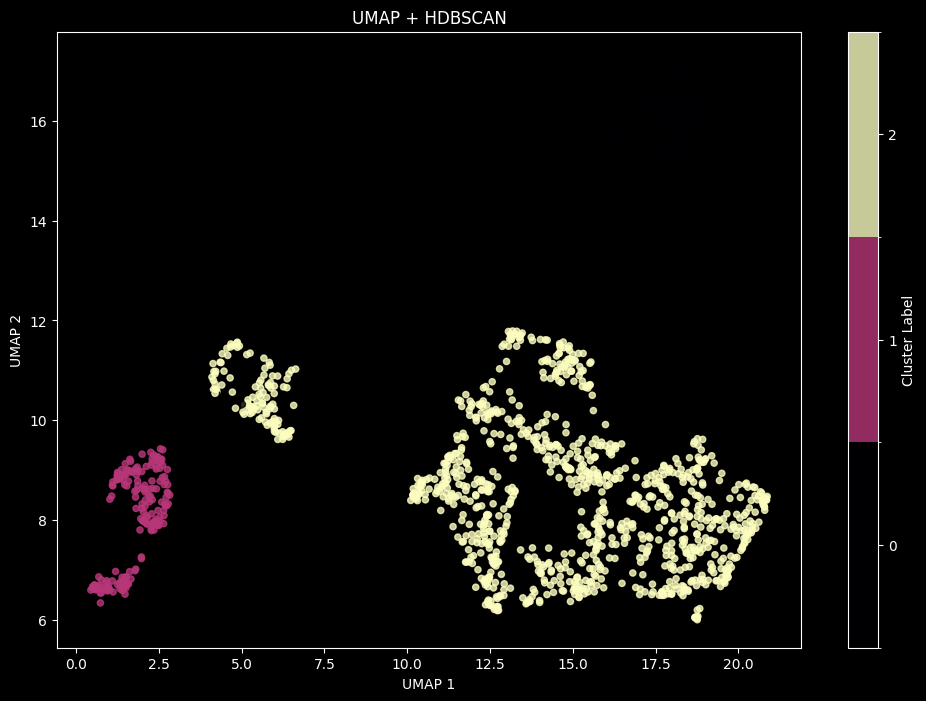

<module 'matplotlib.pyplot' from '/opt/homebrew/Caskroom/miniconda/base/envs/a356/lib/python3.13/site-packages/matplotlib/pyplot.py'>

In [43]:
cmap, norm, ticks, labels = category_cmap(np.unique(clusterer.labels_[clusterer.labels_!=-1]), base_cmap=plt.get_cmap())

plt.scatter(
    features_df[features_df["cluster_stable"]!=-1]["umap_x"],
    features_df[features_df["cluster_stable"]!=-1]["umap_y"],
    c=features_df[features_df["cluster_stable"]!=-1]["cluster_stable"],
    cmap=cmap,
    norm=norm,
    s=20,
    alpha=0.8
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP + HDBSCAN")
plt.colorbar(label="Cluster Label", ticks=ticks, format=lambda v,_: labels[int(v)])
plt.savefig("figures/umap_ogle2025_hdbscan.png", dpi=300, transparent=True)
plt.show()

plt

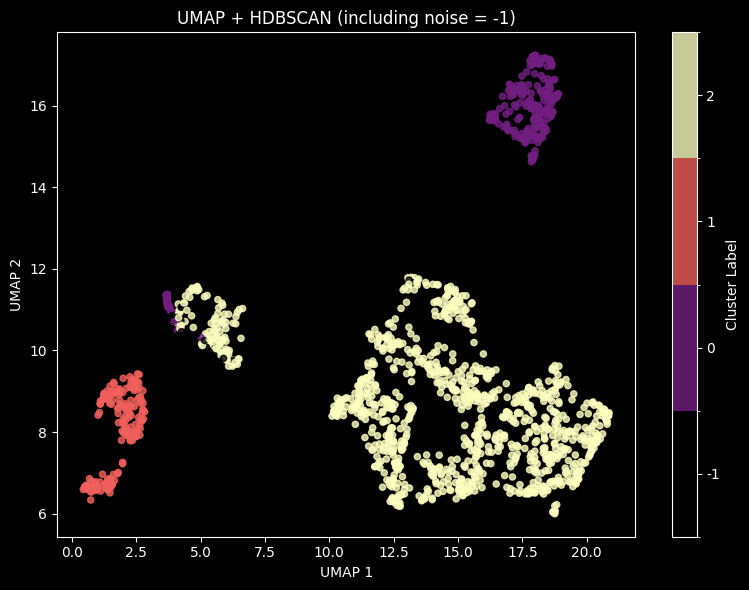

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---------------------------------------------------------
# Category colormap that works for arbitrary label values
# ---------------------------------------------------------
def category_cmap(categories, base_cmap='magma'):
    """
    Create a colormap for arbitrary categorical labels.

    Returns:
        cmap, norm, ticks, ticklabels, label_to_index
    """
    categories = np.asarray(categories)
    N = len(categories)

    # Map actual labels to 0..N-1
    label_to_index = {label: i for i, label in enumerate(categories)}
    index_to_label = {i: label for i, label in enumerate(categories)}

    # Colors
    colors = plt.get_cmap(base_cmap)(np.linspace(0, 1, N))
    cmap = mcolors.ListedColormap(colors)

    # Norm with integer bins
    norm = mcolors.BoundaryNorm(np.arange(N+1), N)

    # Ticks at center of bins
    ticks = np.arange(N) + 0.5
    ticklabels = [index_to_label[i] for i in range(N)]

    return cmap, norm, ticks, ticklabels, label_to_index


# ---------------------------------------------------------
# Build colormap from ALL cluster values (including -1)
# ---------------------------------------------------------
clusters = features_df["cluster_stable"]
unique_labels = np.unique(clusters)

cmap, norm, ticks, ticklabels, label_to_index = category_cmap(unique_labels)

# Convert real labels → color indices for plotting
color_values = clusters.map(label_to_index)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    features_df["umap_x"],
    features_df["umap_y"],
    c=color_values,
    cmap=cmap,
    norm=norm,
    s=20,
    alpha=0.8
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP + HDBSCAN")

# Correctly labeled colorbar
cbar = plt.colorbar(
    ticks=ticks,
    format=lambda v, _: ticklabels[int(v)]
)
cbar.set_label("Cluster Label")

plt.tight_layout()
plt.savefig("figures/umap_ogle2025_hdbscan.png", dpi=300, transparent=True)
plt.show()


# 13. Sample Events per Cluster
- Randomly sample representative events from each cluster  
- Display event identifiers for quick inspection  
- Assess qualitative differences across clusters  

In [14]:
for c in sorted(features_df["cluster_stable"].unique()):
    sample = features_df.query("cluster_stable == @c").sample(min(3, len(features_df.query('cluster_stable == @c'))))
    print(f"\nCluster {c} → sample events:", list(sample["event"]))


Cluster -1 → sample events: ['blg-0023', 'blg-1198', 'blg-1113']

Cluster 0 → sample events: ['blg-0126', 'blg-0221', 'blg-0894']

Cluster 1 → sample events: ['blg-0773', 'blg-0529', 'blg-0774']

Cluster 2 → sample events: ['blg-0847', 'blg-0002', 'blg-0582']


# 15. Light Curve and Model Comparison Plots
- Select sample events from each cluster  
- Plot observed light curves with uncertainties  
- Overlay PSPL model fits when available  
- Annotate plots with key parameter values  

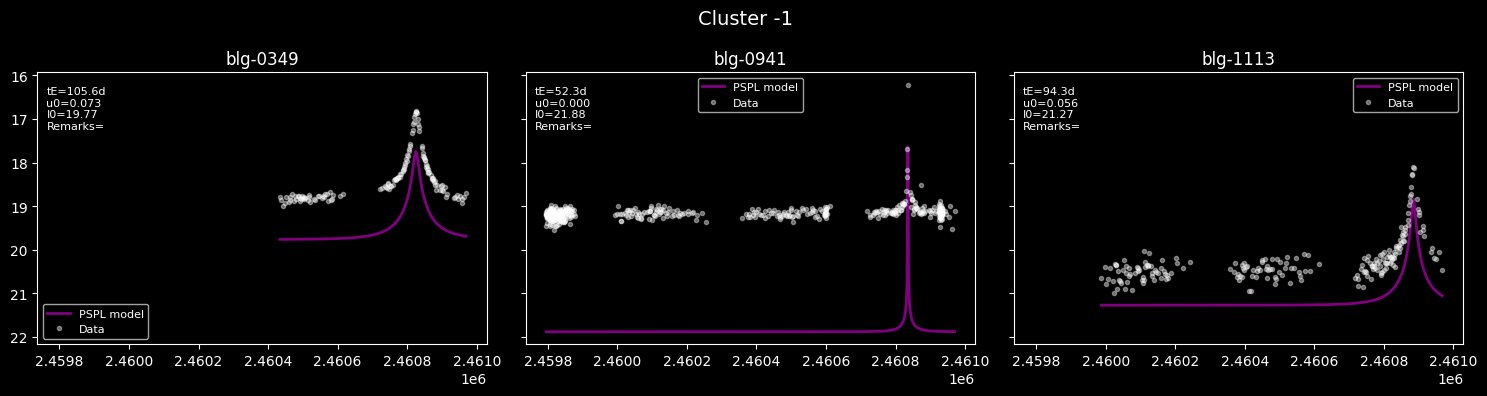

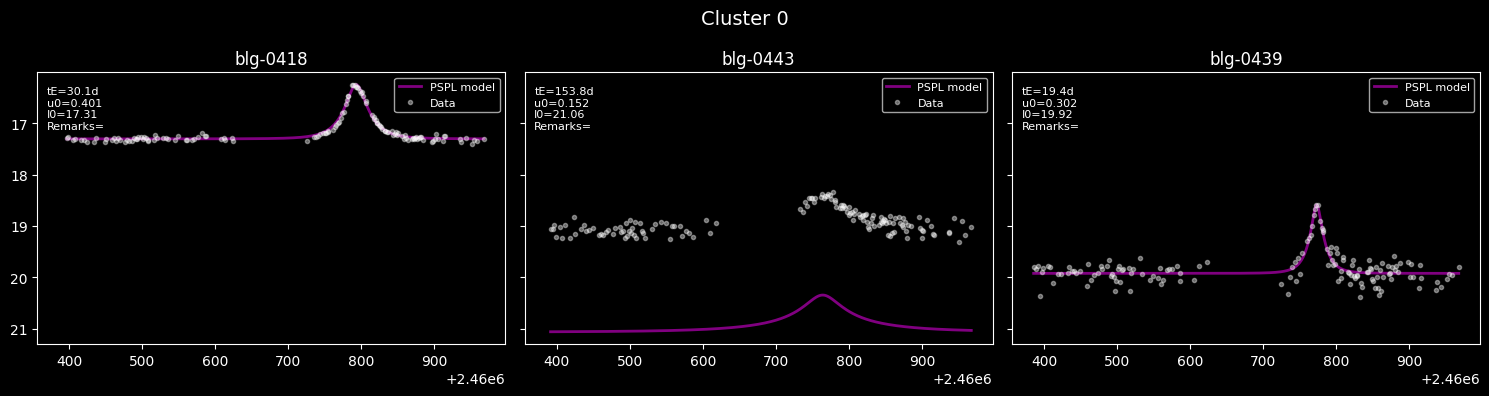

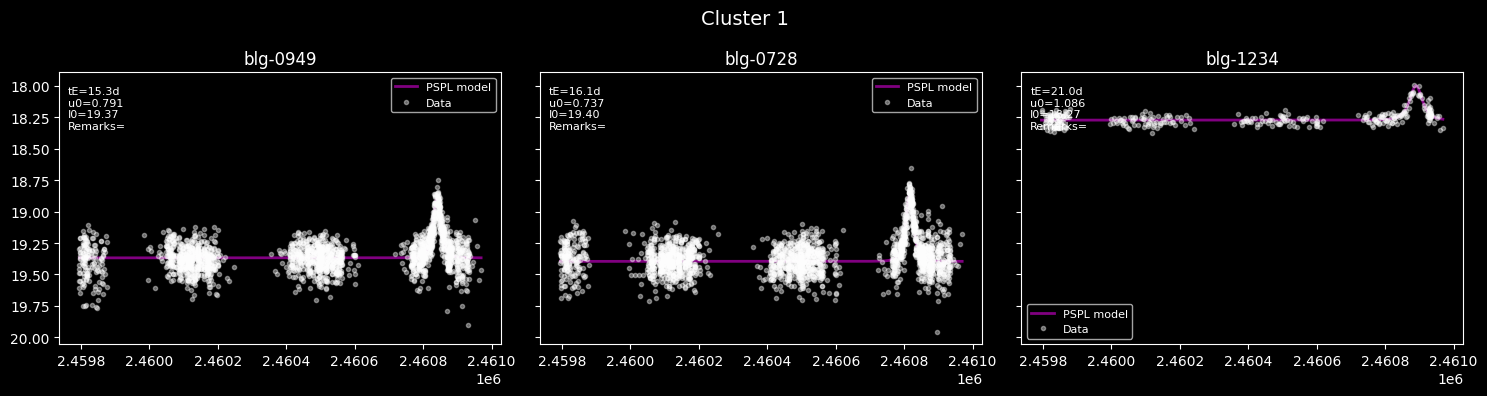

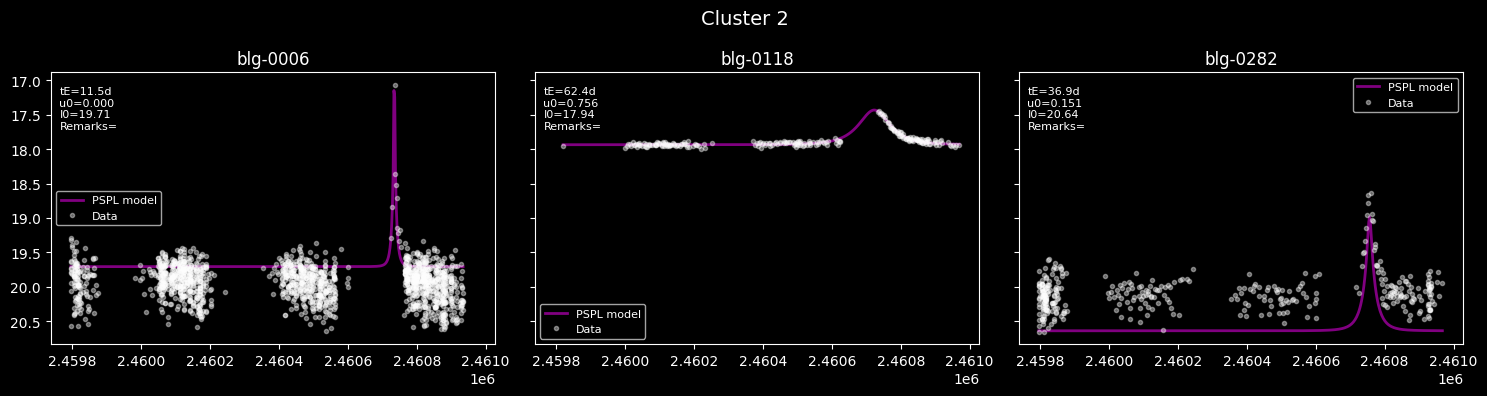

In [15]:
param_dir = "data/raw/ogle4/2025/params"
param_files = sorted([
    os.path.join(param_dir, f) for f in os.listdir(param_dir)
    if f.endswith("_params.dat")
])

params_list = [read_params_file(f) for f in param_files]
params_df = pd.DataFrame(params_list)

all_df = pd.read_parquet("data/processed/ogle2025_lightcurves.parquet", engine="fastparquet")

for c in sorted(features_df["cluster_stable"].unique()):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
    fig.suptitle(f"Cluster {c}", fontsize=14)

    sample = features_df.query("cluster == @c").sample(
        min(3, len(features_df.query('cluster == @c')))
    )

    for ax, event in zip(axs, sample["event"]):
        df = all_df[all_df["event"] == event]
        df = preprocess_lc(df)
        X, Y = df["HJD"].values, df["mag"].values

        # Focus around the event
        i = np.argmin(Y)  # minimum magnitude = peak
        half = 0.4 * (X.max() - X.min())
        mask = (X >= X[i] - half) & (X <= X[i] + half)
        Xc, Yc = X[mask], Y[mask]

        ax.errorbar(Xc, Yc, fmt=".", alpha=0.4, label="Data", color="white")

        # Try to get params
        ev = event.lower()
        try:
            p = params_df.loc[params_df["event"] == ev].iloc[0]
            t0 = p["Tmax"]
            tE = p["tau"]
            u0 = p["umin"]
            I0 = p.get("I0", np.median(Yc))  # fallback if missing
            fbl = p.get("fbl", 1.0)

            t_model = np.linspace(Xc.min(), Xc.max(), 500)
            m_model = pspl_model(t_model, t0, tE, u0, I0, fbl)
            ax.plot(t_model, m_model, "-", lw=2, label="PSPL model", color="purple")

            ax.text(
                0.02, 0.95, f"tE={tE:.1f}d\nu0={u0:.3f}\nI0={I0:.2f}\nRemarks={p['Remarks']}",
                transform=ax.transAxes, va="top", fontsize=8, color="white"
            )

        except Exception as e:
            print(f"⚠️ Skipped {event}: {e}")

        ax.invert_yaxis()
        ax.set_title(event)
        ax.legend(fontsize=8)

    
    plt.tight_layout()
    plt.savefig(f"figures/cluster_{c}_lightcurves_ogle2025.png", dpi=300, transparent=True)
    plt.show()